# Classificação Supervisionada com Gustafson-Kessel (GK) no Dataset DryBean (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Gustafson-Kessel (GK), aplicado ao dataset DryBean com balanceamento das classes via oversampling. Todas as etapas seguem o roteiro didático dos experimentos anteriores, incluindo importação, balanceamento, pré-processamento, método do cotovelo, implementação do GK supervisionado, avaliação, repetição dos experimentos e análise dos resultados.

## 1. Importação das Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

In [2]:
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [3]:
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Cotovelo)

In [5]:
n_clusters = 7  # Definido pelo método do cotovelo

## 6. Implementação do Classificador GK Supervisionado

In [6]:
class GKSupervisionado:
    def __init__(self, n_clusters=7, m=2.0, max_iter=50, tol=1e-5, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_labels_ = None
        self.U_ = None
        self.V_ = None
        self.F_ = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        U = np.random.dirichlet(np.ones(self.n_clusters), size=n_samples).T
        q = self.m
        for _ in range(self.max_iter):
            V = (U ** q) @ X / np.sum(U ** q, axis=1)[:, None]
            F = np.zeros((self.n_clusters, n_features, n_features))
            for i in range(self.n_clusters):
                diff = X - V[i]
                um = (U[i] ** q)[:, None]
                F[i] = (um * diff).T @ diff / np.sum(um)
                F[i] += np.eye(n_features) * 1e-6
            A = np.zeros_like(F)
            for i in range(self.n_clusters):
                detF = np.linalg.det(F[i])
                if detF <= 0:
                    detF = 1e-6
                A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
            D = np.zeros((self.n_clusters, n_samples))
            for i in range(self.n_clusters):
                diff = X - V[i]
                D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
            for i in range(self.n_clusters):
                denom = np.sum((D[i][:, None] / D.T) ** (1 / (q - 1)), axis=1)
                U[i] = 1.0 / denom
        self.U_ = U
        self.V_ = V
        self.F_ = F
        clusters = np.argmax(U, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        q = self.m
        V = self.V_
        F = self.F_
        A = np.zeros_like(F)
        for i in range(self.n_clusters):
            detF = np.linalg.det(F[i])
            if detF <= 0:
                detF = 1e-6
            A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
        D = np.zeros((self.n_clusters, n_samples))
        for i in range(self.n_clusters):
            diff = X - V[i]
            D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
        clusters = np.argmin(D, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.6973
Matriz de Confusão:
[[ 325   85  630    0    7    5   11]
 [   0 1064    0    0    0    0    0]
 [   8    7 1016    0   28    0    5]
 [ 172    0    0    0    0  216  676]
 [   0    0   18    0 1005    0   41]
 [ 138    0    0    0    0  913   13]
 [ 159    0    6    0   23    6  870]]


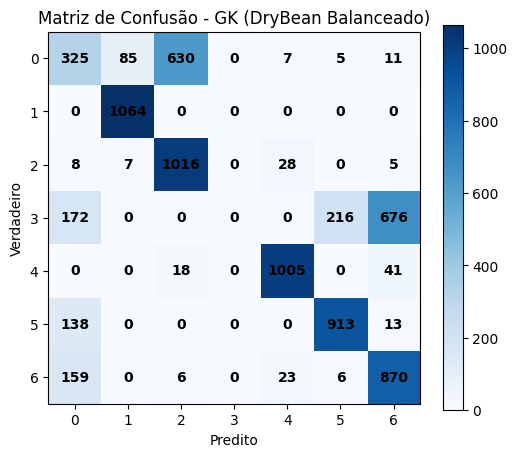

In [7]:
clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - GK (DryBean Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
# Adiciona os valores nas células
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/gk_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

Acurácia média: 0.8006
Desvio padrão da acurácia: 0.0511
MSE médio: 1.9417
Desvio padrão do MSE: 0.8039


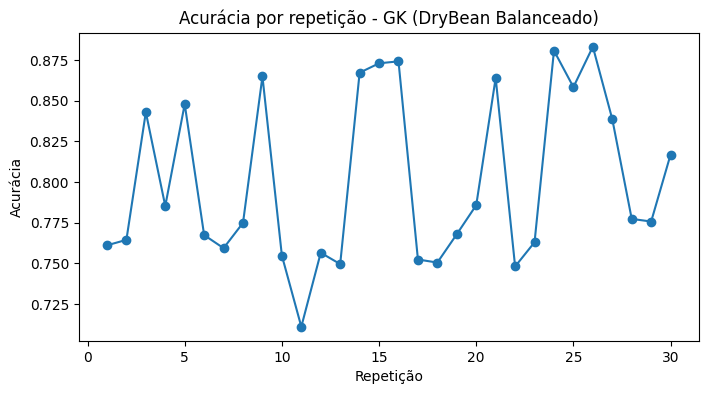

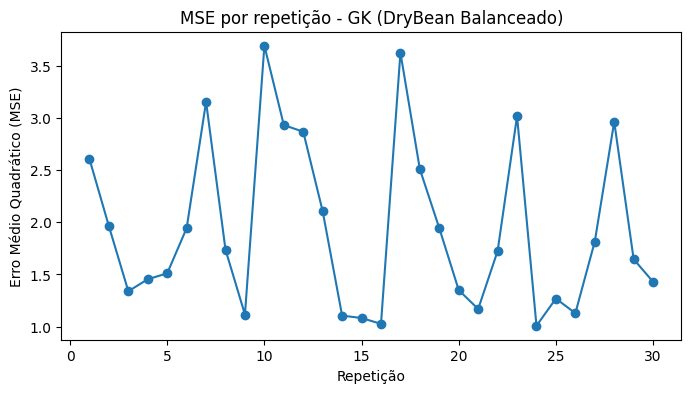

Matriz de Confusão Média:
[[18110   320 10046   298   197   243  2706]
 [  583 31283    50     0     0     0     0]
 [ 2023    22 27907    28   993    68   874]
 [    0     0     0 25530    17  2196  4173]
 [   82     0   944   354 29297     0  1235]
 [  288     0     2  1568     0 29318   742]
 [ 2273     0   136 10874   855   353 17422]]


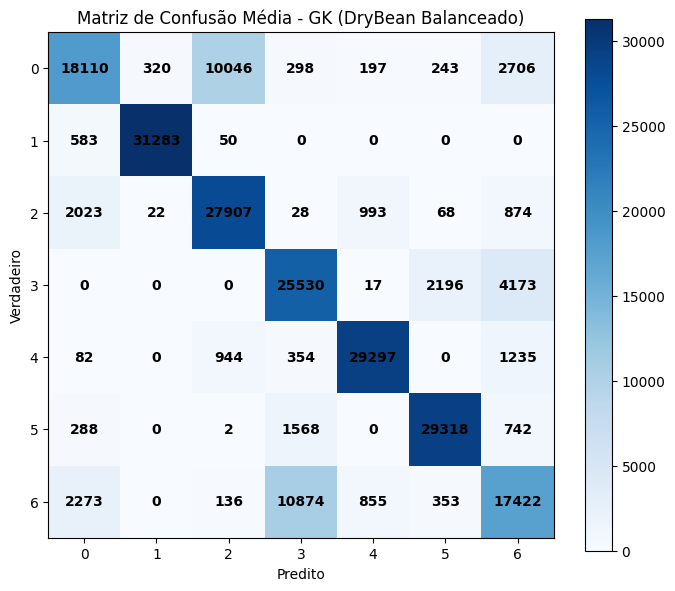

In [8]:
acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - GK (DryBean Balanceado)')
plt.savefig('img/gk_drybean_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - GK (DryBean Balanceado)')
plt.savefig('img/gk_drybean_balance_mse_repetitions.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/gk_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/gk_drybean_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/gk_drybean_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/gk_drybean_balance_mse_repetitions.csv', mse_array, delimiter=',')

# Cálculo e visualização da matriz de confusão média
from sklearn.metrics import confusion_matrix
all_y_true = []
all_y_pred = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
cm_media = confusion_matrix(all_y_true, all_y_pred)
print('Matriz de Confusão Média:')
print(cm_media)
plt.figure(figsize=(7,6))
plt.imshow(cm_media, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média - GK (DryBean Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_media.shape[0]):
    for j in range(cm_media.shape[1]):
        plt.text(j, i, str(cm_media[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/gk_drybean_balance_confusion_matrix_media.png')
plt.show()

## 9. Cálculo das Principais Métricas de Avaliação

## 10. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Gustafson-Kessel (GK) no dataset DryBean balanceado. As principais métricas (acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média) permitem avaliar o desempenho do modelo de forma quantitativa e qualitativa.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados.
- **Matriz de confusão média:** Permite visualizar como os clusters encontrados se relacionam com as classes reais, identificando acertos e erros do agrupamento.
- **Precisão, recall, especificidade e F1-score:** Complementam a análise, mostrando o comportamento do modelo em relação a cada classe.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- Padrões diagonais na matriz de confusão sugerem boa correspondência entre clusters e classes reais.
- Métricas equilibradas indicam que o balanceamento foi eficaz e o modelo não favorece uma classe específica.

**Sugestões:**
- Compare os resultados do GK com outros métodos (KMeans, Agglomerative, Fuzzy C-Means) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere a visualização dos agrupamentos (PCA) para interpretar a separação dos grupos no espaço de atributos.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calcular_metricas_multiclasse(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade média: média das especificidades de cada classe
    especificidades = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        especificidades.append(especificidade)
    especificidade_media = np.mean(especificidades)
    return acc, prec, rec, especificidade_media, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas_multiclasse(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))

Acurácia média: 0.8006
Precisão média: 0.7690
Recall médio: 0.8006
Especificidade média: 0.9668
F1-score médio: 0.7750
Matriz de confusão média:
[[6.03670e+02 1.06700e+01 3.34870e+02 9.93000e+00 6.57000e+00 8.10000e+00
  9.02000e+01]
 [1.94300e+01 1.04277e+03 1.67000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00]
 [6.74300e+01 7.30000e-01 9.30230e+02 9.30000e-01 3.31000e+01 2.27000e+00
  2.91300e+01]
 [0.00000e+00 0.00000e+00 0.00000e+00 8.51000e+02 5.70000e-01 7.32000e+01
  1.39100e+02]
 [2.73000e+00 0.00000e+00 3.14700e+01 1.18000e+01 9.76570e+02 0.00000e+00
  4.11700e+01]
 [9.60000e+00 0.00000e+00 7.00000e-02 5.22700e+01 0.00000e+00 9.77270e+02
  2.47300e+01]
 [7.57700e+01 0.00000e+00 4.53000e+00 3.62470e+02 2.85000e+01 1.17700e+01
  5.80730e+02]]
